# No-fracture control: CG, CG+PINN reconstruction, and MRST/TPFA transport

This is the no-fracture counterpart of the boundary-tip transport notebook.  The fracture is removed completely; the pressure problem is the matrix-only left/right Dirichlet problem used in the MRST no-fracture export.  The transport comparison keeps the same three flux choices used in the fracture notebook:

- raw CG flux \(\mathbf v_h\),
- CG+PINN reconstructed flux \(\mathbf v_\theta\),
- MRST/TPFA finite-volume flux.


In [7]:
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat

try:
    import torch
    import torch.nn as nn
    from tqdm.auto import tqdm
    TORCH_AVAILABLE = True
except ModuleNotFoundError:
    torch = None
    nn = None
    TORCH_AVAILABLE = False
    def tqdm(iterable, **kwargs):
        return iterable

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
})

np.random.seed(1234)
if TORCH_AVAILABLE:
    torch.manual_seed(1234)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
else:
    device = "numpy"

MRST_NOFRACTURE_FILE = pathlib.Path("case3_ecmor/case3_mrst_export_nofrac.mat")
if not MRST_NOFRACTURE_FILE.exists():
    MRST_NOFRACTURE_FILE = pathlib.Path("fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export_nofrac.mat")
if not MRST_NOFRACTURE_FILE.exists():
    raise FileNotFoundError("Could not find case3_mrst_export_nofrac.mat from the notebook or repository root.")

mat = loadmat(MRST_NOFRACTURE_FILE, squeeze_me=True, struct_as_record=False)

NOFRACTURE_SAVE_FIGURES = True
NOFRACTURE_OUTDIR = pathlib.Path("result_koppel_martin_case1_no_fracture_transport")
NOFRACTURE_OUTDIR.mkdir(exist_ok=True)


def _arr(name, dtype=float):
    if name not in mat:
        raise KeyError(f"Missing required MRST field {name!r}")
    return np.asarray(mat[name], dtype=dtype)


def _meta_float(name, default=np.nan):
    if name not in mat:
        return float(default)
    return float(np.asarray(mat[name]).squeeze())


xc_matrix = _arr("xc_matrix", float)
face_neighbors = _arr("face_neighbors", int)
face_flux_mrst_global = _arr("face_flux", float).reshape(-1)
face_centroid = _arr("face_centroid", float)
face_normal = _arr("face_normal", float)
face_len = _arr("face_len", float).reshape(-1)
face_p1 = _arr("face_p1", float)
face_p2 = _arr("face_p2", float)

nx, ny = np.asarray(mat["meta_celldim"], dtype=int).reshape(-1)
physdim = np.asarray(mat["meta_physdim"], dtype=float).reshape(-1)
phi_matrix = _meta_float("meta_phi_matrix", 1.0)
PV_matrix = _meta_float("meta_PV_matrix", phi_matrix * np.prod(physdim))
Q_water = _meta_float("meta_Q_water", np.nan)
CFL = _meta_float("meta_CFL", 0.45)
FPRIME_MAX = _meta_float("meta_FPRIME_MAX", 2.0)

sw_mrst_native = {}
sw_mrst_matched = {}
transport_times = {}
transport_pvi = {}
transport_case_labels = {}

def _add_transport_case(key, sw_field, matched_field, T_value, pvi_value, label):
    sw_mrst_native[key] = _arr(sw_field, float).reshape(-1)
    sw_mrst_matched[key] = _arr(matched_field, float).reshape(-1)
    transport_times[key] = float(T_value)
    transport_pvi[key] = float(pvi_value)
    transport_case_labels[key] = label

# Prefer visible-front no-fracture snapshots when present in the updated MRST export.
if "sw_matrix_pvi05" in mat:
    T_pvi05 = _meta_float("meta_T_pvi05")
    pvi05 = Q_water * T_pvi05 / PV_matrix if np.isfinite(Q_water) and PV_matrix > 0 else 0.5
    _add_transport_case("PVI0.5", "sw_matrix_pvi05", "sw_matrix_pvi05_matched", T_pvi05, pvi05, "PVI=0.5")
if "sw_matrix_t020" in mat:
    _add_transport_case("T0.2", "sw_matrix_t020", "sw_matrix_t020_matched", _meta_float("meta_T_t020"), _meta_float("meta_PVI_t020"), "T=0.2")

# Fallback to the original later snapshots if the updated fields are absent.
if not sw_mrst_native:
    _add_transport_case("T1", "sw_matrix_t1", "sw_matrix_t1_matched", _meta_float("meta_T1"), _meta_float("meta_PVI1"), "T1")
    _add_transport_case("T2", "sw_matrix_t2", "sw_matrix_t2_matched", _meta_float("meta_T2"), _meta_float("meta_PVI2"), "T2")

transport_case_keys = list(sw_mrst_native.keys())

ncell = int(xc_matrix.shape[0])
cell_pv = np.full(ncell, PV_matrix / ncell, dtype=float)
cell_area = cell_pv / phi_matrix

xmin, ymin = 0.0, 0.0
xmax, ymax = float(physdim[0]), float(physdim[1])

print(f"Loaded {MRST_NOFRACTURE_FILE}")
print(f"No-fracture grid: {nx} x {ny}, cells={ncell}, faces={face_flux_mrst_global.size}")
print(f"Q_water={Q_water:.8e}, PV_matrix={PV_matrix:.8e}, CFL={CFL:.3f}")
print("Transport snapshots used:")
for key in transport_case_keys:
    print(f"  {key}: T={transport_times[key]:.8e}, PVI={transport_pvi[key]:.6f}, MRST Sw=[{sw_mrst_native[key].min():.3e}, {sw_mrst_native[key].max():.3e}]")


Loaded case3_ecmor/case3_mrst_export_nofrac.mat
No-fracture grid: 128 x 128, cells=16384, faces=33024
Q_water=3.00000000e+00, PV_matrix=1.00000000e+00, CFL=0.450
Transport snapshots used:
  PVI0.5: T=1.66666667e-01, PVI=0.500000, MRST Sw=[0.000e+00, 9.863e-01]
  T0.2: T=2.00000000e-01, PVI=0.600000, MRST Sw=[0.000e+00, 9.884e-01]


/home/muchamad/PhD/fenicsx/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
# Matrix-only CG pressure solve for the no-fracture problem.
# For p_left=1, p_right=4, k_m=1, no-flow top/bottom, the Q1 CG solution is exact:
#   p_h(x,y)=1+3x,    v_h=-grad p_h=(-3,0).
K_M_VALUE = 1.0
P_LEFT = 1.0
P_RIGHT = 4.0
PRESSURE_GRAD_X = (P_RIGHT - P_LEFT) / physdim[0]


def p_cg_numpy(points):
    points = np.asarray(points, dtype=float)
    return P_LEFT + PRESSURE_GRAD_X * points[:, 0]


def v_cg_numpy(points):
    points = np.asarray(points, dtype=float)
    values = np.zeros((points.shape[0], 2), dtype=float)
    values[:, 0] = -K_M_VALUE * PRESSURE_GRAD_X
    values[:, 1] = 0.0
    return values


p_matrix_cg = p_cg_numpy(xc_matrix)
print(f"CG pressure p_h range: [{p_matrix_cg.min():.6f}, {p_matrix_cg.max():.6f}]")
print(f"CG Darcy velocity v_h = ({-K_M_VALUE * PRESSURE_GRAD_X:.6f}, 0)")
print(f"MRST pressure comparison: mean|p_h-p_FV|={np.mean(np.abs(p_matrix_cg - _arr('p_matrix', float).reshape(-1))):.3e}, max|p_h-p_FV|={np.max(np.abs(p_matrix_cg - _arr('p_matrix', float).reshape(-1))):.3e}")


CG pressure p_h range: [1.011719, 3.988281]
CG Darcy velocity v_h = (-3.000000, 0)
MRST pressure comparison: mean|p_h-p_FV|=4.397e-13, max|p_h-p_FV|=6.772e-13


In [9]:
# MRST face orientation -> owner/neighbour connection list.
# Fout is positive outward from owner; for an interior face it is positive owner -> neighbour.
n1 = face_neighbors[:, 0].astype(int)
n2 = face_neighbors[:, 1].astype(int)
is_internal_face = (n1 > 0) & (n2 > 0)
is_boundary_face = ~is_internal_face

owner_int = n1[is_internal_face] - 1
neigh_int = n2[is_internal_face] - 1
owner_b = np.maximum(n1[is_boundary_face], n2[is_boundary_face]) - 1
sgn_b = np.ones(np.count_nonzero(is_boundary_face), dtype=float)
sgn_b[n1[is_boundary_face] == 0] = -1.0

owner = np.concatenate([owner_int, owner_b]).astype(int)
neigh = np.concatenate([neigh_int, -np.ones_like(owner_b)]).astype(int)
has_neighbor = neigh >= 0
is_boundary_conn = ~has_neighbor

RIGHT_BC_S = 1.0
inlet_s_b = np.zeros_like(owner_b, dtype=float)
inlet_s_b[np.isclose(face_centroid[is_boundary_face, 0], physdim[0], atol=1.0e-10)] = RIGHT_BC_S
inlet_s = np.concatenate([np.zeros_like(owner_int, dtype=float), inlet_s_b])


def global_face_flux_to_fout(global_face_flux):
    global_face_flux = np.asarray(global_face_flux, dtype=float).reshape(-1)
    return np.concatenate([
        global_face_flux[is_internal_face],
        global_face_flux[is_boundary_face] * sgn_b,
    ]).astype(float)


def face_global_flux_from_velocity(velocity_fn, n_quad=2):
    if n_quad == 1:
        xi = np.array([0.5], dtype=float)
        wi = np.array([1.0], dtype=float)
    elif n_quad == 2:
        a = 0.5 / np.sqrt(3.0)
        xi = np.array([0.5 - a, 0.5 + a], dtype=float)
        wi = np.array([0.5, 0.5], dtype=float)
    else:
        xi, wi = np.polynomial.legendre.leggauss(n_quad)
        xi = 0.5 * (xi + 1.0)
        wi = 0.5 * wi
    flux = np.zeros(face_len.size, dtype=float)
    edge = face_p2 - face_p1
    for s, w in zip(xi, wi):
        pts = face_p1 + s * edge
        vel = velocity_fn(pts)
        flux += w * face_len * np.einsum("ij,ij->i", vel, face_normal)
    return flux


face_flux_cg_global = face_global_flux_from_velocity(v_cg_numpy, n_quad=1)
Fout_CG = global_face_flux_to_fout(face_flux_cg_global)
Fout_MRST = global_face_flux_to_fout(face_flux_mrst_global)

print("CG face flux vs MRST TPFA face flux:")
print(f"  mean|e|={np.mean(np.abs(Fout_CG - Fout_MRST)):.3e}")
print(f"  max |e|={np.max(np.abs(Fout_CG - Fout_MRST)):.3e}")
print(f"  right-boundary CG inflow={np.sum(np.maximum(-Fout_CG[owner_int.size:], 0.0)):.8e}")
print(f"  right-boundary MRST inflow={np.sum(np.maximum(-Fout_MRST[owner_int.size:], 0.0)):.8e}")


CG face flux vs MRST TPFA face flux:
  mean|e|=5.506e-15
  max |e|=2.842e-14
  right-boundary CG inflow=3.00000000e+00
  right-boundary MRST inflow=3.00000000e+00


In [10]:
# CG+PINN reconstruction in the no-fracture case.
# We use a correction form v_theta = v_h + r_theta.  Since the no-fracture CG
# pressure is exact and locally conservative here, the correct correction is r_theta = 0.
RUN_PINN_TRAINING = True
PINN_EPOCHS = 50
PINN_N_INTERIOR = 8192
PINN_N_BOUNDARY = 2048
PINN_LR = 1.0e-3
W_CORRECTION_DATA = 1.0
W_DIV = 0.1
W_NOFLOW = 1.0
pinn_history = {"epoch": [], "loss": [], "data": [], "div": [], "noflow": []}
pinn_training_time = 0.0

if TORCH_AVAILABLE:
    class CorrectionFluxNet(nn.Module):
        def __init__(self, hidden_dim=32, depth=2):
            super().__init__()
            layers = []
            last = 2
            for _ in range(depth):
                layer = nn.Linear(last, hidden_dim)
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)
                layers += [layer, nn.Tanh()]
                last = hidden_dim
            out = nn.Linear(last, 2)
            nn.init.zeros_(out.weight)
            nn.init.zeros_(out.bias)
            layers.append(out)
            self.net = nn.Sequential(*layers)
            self.register_buffer("center", torch.tensor([0.5 * physdim[0], 0.5 * physdim[1]], dtype=torch.float32))
            self.register_buffer("scale", torch.tensor(max(physdim), dtype=torch.float32))

        def forward(self, x):
            z = 2.0 * (x - self.center) / self.scale
            return self.net(z)


    def div_correction(net, x):
        x = x.clone().detach().requires_grad_(True)
        r = net(x)
        dr0 = torch.autograd.grad(r[:, 0].sum(), x, create_graph=True, retain_graph=True)[0][:, 0]
        dr1 = torch.autograd.grad(r[:, 1].sum(), x, create_graph=True, retain_graph=True)[0][:, 1]
        return dr0 + dr1


    correction_net = CorrectionFluxNet().to(device)

    if RUN_PINN_TRAINING:
        opt = torch.optim.Adam(correction_net.parameters(), lr=PINN_LR)
        t0 = time.perf_counter()
        for epoch in tqdm(range(PINN_EPOCHS), desc="No-fracture PINN correction"):
            opt.zero_grad()
            x_int_np = np.column_stack([
                np.random.rand(PINN_N_INTERIOR) * physdim[0],
                np.random.rand(PINN_N_INTERIOR) * physdim[1],
            ])
            x_int = torch.as_tensor(x_int_np, dtype=torch.float32, device=device)
            r_int = correction_net(x_int)
            data_loss = torch.mean(r_int**2)
            div_loss = torch.mean(div_correction(correction_net, x_int)**2)

            xb = np.random.rand(PINN_N_BOUNDARY) * physdim[0]
            yb = np.where(np.random.rand(PINN_N_BOUNDARY) < 0.5, 0.0, physdim[1])
            x_bnd = torch.as_tensor(np.column_stack([xb, yb]), dtype=torch.float32, device=device)
            r_bnd = correction_net(x_bnd)
            noflow_loss = torch.mean(r_bnd[:, 1] ** 2)

            loss = W_CORRECTION_DATA * data_loss + W_DIV * div_loss + W_NOFLOW * noflow_loss
            loss.backward()
            opt.step()

            if epoch == 0 or epoch == PINN_EPOCHS - 1 or (epoch + 1) % max(1, PINN_EPOCHS // 5) == 0:
                pinn_history["epoch"].append(epoch)
                pinn_history["loss"].append(float(loss.detach().cpu()))
                pinn_history["data"].append(float(data_loss.detach().cpu()))
                pinn_history["div"].append(float(div_loss.detach().cpu()))
                pinn_history["noflow"].append(float(noflow_loss.detach().cpu()))
        pinn_training_time = time.perf_counter() - t0


    def correction_numpy(points):
        correction_net.eval()
        pts = torch.as_tensor(np.asarray(points, dtype=np.float32), dtype=torch.float32, device=device)
        with torch.no_grad():
            r = correction_net(pts).cpu().numpy().astype(float)
        return r
else:
    correction_net = None

    def correction_numpy(points):
        points = np.asarray(points, dtype=float)
        return np.zeros((points.shape[0], 2), dtype=float)


def v_pinn_numpy(points):
    points = np.asarray(points, dtype=float)
    return v_cg_numpy(points) + correction_numpy(points)


probe = np.random.rand(10000, 2) * physdim[None, :]
r_probe = correction_numpy(probe)
print(f"Torch available for PINN training: {TORCH_AVAILABLE}")
if not TORCH_AVAILABLE:
    print("Using exact zero PINN correction; this is the no-fracture optimum because v_h is already exact and conservative.")
print(f"PINN correction training time: {pinn_training_time:.3f} s")
print(f"PINN correction |r_theta|: mean={np.mean(np.linalg.norm(r_probe, axis=1)):.3e}, max={np.max(np.linalg.norm(r_probe, axis=1)):.3e}")
if pinn_history["epoch"]:
    print("PINN correction loss history:")
    for e, loss, data, div, nf in zip(pinn_history["epoch"], pinn_history["loss"], pinn_history["data"], pinn_history["div"], pinn_history["noflow"]):
        print(f"  epoch={e:4d} loss={loss:.3e} data={data:.3e} div={div:.3e} noflow={nf:.3e}")


No-fracture PINN correction: 100%|██████████| 50/50 [00:01<00:00, 39.68it/s]

Torch available for PINN training: True
PINN correction training time: 1.268 s
PINN correction |r_theta|: mean=0.000e+00, max=0.000e+00
PINN correction loss history:
  epoch=   0 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=   9 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  19 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  29 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  39 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00
  epoch=  49 loss=0.000e+00 data=0.000e+00 div=0.000e+00 noflow=0.000e+00


In [11]:
# Build face fluxes for CG+PINN and check single-phase local conservation.
face_flux_PINN_global = face_global_flux_from_velocity(v_pinn_numpy, n_quad=2)
Fout_PINN = global_face_flux_to_fout(face_flux_PINN_global)

transport_fluxes = {
    "CG": Fout_CG,
    "PINN": Fout_PINN,
    "MRST": Fout_MRST,
}


def cell_single_phase_residual(Fout):
    residual = np.zeros(ncell, dtype=float)
    np.add.at(residual, owner, Fout)
    np.add.at(residual, neigh[has_neighbor], -Fout[has_neighbor])
    return residual


print("No-fracture face-flux comparison relative to MRST/TPFA:")
for name, Fout in transport_fluxes.items():
    err = Fout - Fout_MRST
    print(f"  {name:<4} mean|F-F_FV|={np.mean(np.abs(err)):.3e}, rmse={np.sqrt(np.mean(err**2)):.3e}, max|F-F_FV|={np.max(np.abs(err)):.3e}")

print("No-fracture single-phase cell balance, sum outward face flux:")
for name, Fout in transport_fluxes.items():
    r = cell_single_phase_residual(Fout)
    print(f"  {name:<4} mean|r|={np.mean(np.abs(r)):.3e}, rmse={np.sqrt(np.mean(r**2)):.3e}, max|r|={np.max(np.abs(r)):.3e}, sum(r)={np.sum(r):+.3e}")


No-fracture face-flux comparison relative to MRST/TPFA:
  CG   mean|F-F_FV|=5.506e-15, rmse=8.585e-15, max|F-F_FV|=2.842e-14
  PINN mean|F-F_FV|=5.506e-15, rmse=8.585e-15, max|F-F_FV|=2.842e-14
  MRST mean|F-F_FV|=0.000e+00, rmse=0.000e+00, max|F-F_FV|=0.000e+00
No-fracture single-phase cell balance, sum outward face flux:
  CG   mean|r|=0.000e+00, rmse=0.000e+00, max|r|=0.000e+00, sum(r)=+0.000e+00
  PINN mean|r|=0.000e+00, rmse=0.000e+00, max|r|=0.000e+00, sum(r)=+0.000e+00
  MRST mean|r|=8.922e-16, rmse=1.269e-15, max|r|=1.332e-14, sum(r)=+5.080e-12


In [12]:
def fractional_flow_bl(S):
    S = np.asarray(S, dtype=float)
    return S**2 / (S**2 + (1.0 - S)**2 + 1.0e-30)


def compute_transport_dt(Fout):
    outflow = np.zeros(ncell, dtype=float)
    np.add.at(outflow, owner, np.maximum(Fout, 0.0))
    np.add.at(outflow, neigh[has_neighbor], np.maximum(-Fout[has_neighbor], 0.0))
    active = outflow > 1.0e-30
    return CFL * np.min(cell_pv[active] / (FPRIME_MAX * outflow[active]))


def advance_no_fracture_transport(Fout, t_final, dt_scale=1.0, clip=True, nsteps_override=None):
    Fout = np.asarray(Fout, dtype=float)
    dt_cfl = compute_transport_dt(Fout)
    if nsteps_override is None:
        dt_limit = dt_cfl * float(dt_scale)
        nsteps = max(1, int(np.ceil(float(t_final) / dt_limit)))
        dt_source = "method CFL"
    else:
        nsteps = max(1, int(nsteps_override))
        dt_source = "MRST/reference shared"
    dt = float(t_final) / nsteps
    dt_over_pv = dt / cell_pv

    outward = Fout >= 0.0
    incoming_boundary = (~outward) & is_boundary_conn
    up_cell = np.empty_like(owner)
    up_cell[outward] = owner[outward]
    interior_negative = (~outward) & has_neighbor
    up_cell[interior_negative] = neigh[interior_negative]
    up_cell[incoming_boundary] = owner[incoming_boundary]
    boundary_water_flux = fractional_flow_bl(inlet_s) * Fout

    S = np.zeros(ncell, dtype=float)
    cumulative_in = 0.0
    cumulative_out = 0.0
    preclip_min = 0.0
    preclip_max = 0.0
    clipped_count = 0
    clip_mass_delta = 0.0

    for _ in range(nsteps):
        w = fractional_flow_bl(S[up_cell]) * Fout
        w[incoming_boundary] = boundary_water_flux[incoming_boundary]
        wb = w[is_boundary_conn]
        cumulative_in += dt * np.sum(np.maximum(-wb, 0.0))
        cumulative_out += dt * np.sum(np.maximum(wb, 0.0))

        div = np.zeros(ncell, dtype=float)
        np.add.at(div, owner, w)
        np.add.at(div, neigh[has_neighbor], -w[has_neighbor])
        S_new = S - dt_over_pv * div
        preclip_min = min(preclip_min, float(np.min(S_new)))
        preclip_max = max(preclip_max, float(np.max(S_new)))
        if clip:
            S_clip = np.clip(S_new, 0.0, 1.0)
            clipped_count += int(np.count_nonzero(S_clip != S_new))
            clip_mass_delta += float(np.sum((S_clip - S_new) * cell_pv))
            S = S_clip
        else:
            S = S_new

    mass = float(np.sum(S * cell_pv))
    net = float(cumulative_in - cumulative_out)
    return S, {
        "T": float(t_final),
        "dt": float(dt),
        "dt_cfl": float(dt_cfl),
        "dt_scale": float(dt_scale),
        "nsteps": int(nsteps),
        "dt_source": dt_source,
        "water_in": float(cumulative_in),
        "water_out": float(cumulative_out),
        "water_net": net,
        "water_mass": mass,
        "water_balance_error": float(mass - net),
        "water_balance_error_pct_in": float(100.0 * (mass - net) / cumulative_in) if cumulative_in > 0 else np.nan,
        "preclip_min": float(preclip_min),
        "preclip_max": float(preclip_max),
        "clip_mass_delta": float(clip_mass_delta),
        "clipped_count": int(clipped_count),
        "right_inflow": float(np.sum(np.maximum(-Fout[owner_int.size:], 0.0))),
        "pvi": float(t_final * np.sum(np.maximum(-Fout[owner_int.size:], 0.0)) / PV_matrix),
    }


def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))


def maxabs(a, b):
    return float(np.max(np.abs(np.asarray(a) - np.asarray(b))))


NOFRACTURE_CLIP = True
NOFRACTURE_DT_SCALES = [1.0, 0.5]
NOFRACTURE_USE_MRST_REFERENCE_DT = True


def _case_meta_candidates(key, stem):
    key_lower = key.lower().replace(".", "")
    out = [f"meta_{stem}_{key_lower}"]
    if key == "PVI0.5":
        out += [f"meta_{stem}_pvi05", f"meta_{stem}_pvi_05"]
    if key == "T0.2":
        out += [f"meta_{stem}_t020", f"meta_{stem}_t02"]
    if key == "T1":
        out += [f"meta_{stem}1", f"meta_{stem}_t1"]
    if key == "T2":
        out += [f"meta_{stem}2", f"meta_{stem}_t2"]
    return out


def _optional_meta_float(names):
    for name in names:
        if name in mat:
            return _meta_float(name)
    return np.nan


def reference_nsteps_for_case(key):
    # Exact native MRST explicitTransport substeps are not present in the current export.
    # If a future export provides meta_nsteps_* or meta_dt_*, use that. Otherwise use
    # the shared MRST/TPFA CFL timestep from the exported conservative face flux.
    nsteps_meta = _optional_meta_float(_case_meta_candidates(key, "nsteps"))
    if np.isfinite(nsteps_meta) and nsteps_meta > 0:
        return int(round(nsteps_meta)), "exported meta_nsteps"
    dt_meta = _optional_meta_float(_case_meta_candidates(key, "dt"))
    if np.isfinite(dt_meta) and dt_meta > 0:
        return max(1, int(np.ceil(transport_times[key] / dt_meta))), "exported meta_dt"
    dt_ref = compute_transport_dt(Fout_MRST)
    return max(1, int(np.ceil(transport_times[key] / dt_ref))), "MRST/TPFA CFL from exported face flux"


reference_nsteps = {}
reference_dt_source = {}
for key in transport_case_keys:
    reference_nsteps[key], reference_dt_source[key] = reference_nsteps_for_case(key)

print("Shared transport timestep policy:")
for key in transport_case_keys:
    print(
        f"  {key}: nsteps_ref={reference_nsteps[key]}, "
        f"dt_ref={transport_times[key] / reference_nsteps[key]:.8e}, "
        f"source={reference_dt_source[key]}"
    )
transport_results = {}
for scale in NOFRACTURE_DT_SCALES:
    transport_results[scale] = {}
    for key in transport_case_keys:
        transport_results[scale][key] = {}
        for name, Fout in transport_fluxes.items():
            nsteps_override = None
            if NOFRACTURE_USE_MRST_REFERENCE_DT:
                nsteps_override = int(np.ceil(reference_nsteps[key] / scale))
            S, meta = advance_no_fracture_transport(
                Fout,
                transport_times[key],
                dt_scale=scale,
                clip=NOFRACTURE_CLIP,
                nsteps_override=nsteps_override,
            )
            transport_results[scale][key][name] = {"S": S, "meta": meta}

print("No-fracture transport diagnostics relative to native MRST explicitTransport")
print("  dt_scale  time method     nsteps        dt       PVI      RMSE      max|e|    balance %in   dt source")
for scale in NOFRACTURE_DT_SCALES:
    for key in transport_case_keys:
        for name in ("CG", "PINN", "MRST"):
            item = transport_results[scale][key][name]
            S = item["S"]
            meta = item["meta"]
            print(
                f"  {scale:8.3f}  {key:<2}   {name:<5} "
                f"{meta['nsteps']:8d} {meta['dt']:10.4e} {meta['pvi']:8.4f} "
                f"{rmse(S, sw_mrst_native[key]):9.3e} {maxabs(S, sw_mrst_native[key]):9.3e} "
                f"{meta['water_balance_error_pct_in']:12.3e}   {meta['dt_source']}"
            )

print("\nNative MRST explicitTransport vs exported hand-coded matched saturation")
for key in transport_case_keys:
    print(f"  {key}: RMSE={rmse(sw_mrst_matched[key], sw_mrst_native[key]):.4e}, max|e|={maxabs(sw_mrst_matched[key], sw_mrst_native[key]):.4e}")

print("\nTime-step refinement for notebook transport, dt vs dt/2")
for key in transport_case_keys:
    for name in ("CG", "PINN", "MRST"):
        S1 = transport_results[1.0][key][name]["S"]
        S2 = transport_results[0.5][key][name]["S"]
        print(f"  {key} {name:<5}: RMSE={rmse(S1, S2):.4e}, max|e|={maxabs(S1, S2):.4e}")


Shared transport timestep policy:
  PVI0.5: nsteps_ref=285, dt_ref=5.84795322e-04, source=MRST/TPFA CFL from exported face flux
  T0.2: nsteps_ref=342, dt_ref=5.84795322e-04, source=MRST/TPFA CFL from exported face flux
No-fracture transport diagnostics relative to native MRST explicitTransport
  dt_scale  time method     nsteps        dt       PVI      RMSE      max|e|    balance %in   dt source
     1.000  PVI0.5   CG         285 5.8480e-04   0.5000 3.052e-03 3.189e-02    5.551e-13   MRST/reference shared
     1.000  PVI0.5   PINN       285 5.8480e-04   0.5000 3.052e-03 3.189e-02    5.551e-13   MRST/reference shared
     1.000  PVI0.5   MRST       285 5.8480e-04   0.5000 3.052e-03 3.189e-02   -2.442e-13   MRST/reference shared
     1.000  T0.2   CG         342 5.8480e-04   0.6000 3.214e-03 3.411e-02   -2.591e-13   MRST/reference shared
     1.000  T0.2   PINN       342 5.8480e-04   0.6000 3.214e-03 3.411e-02   -2.591e-13   MRST/reference shared
     1.000  T0.2   MRST       342 5.848

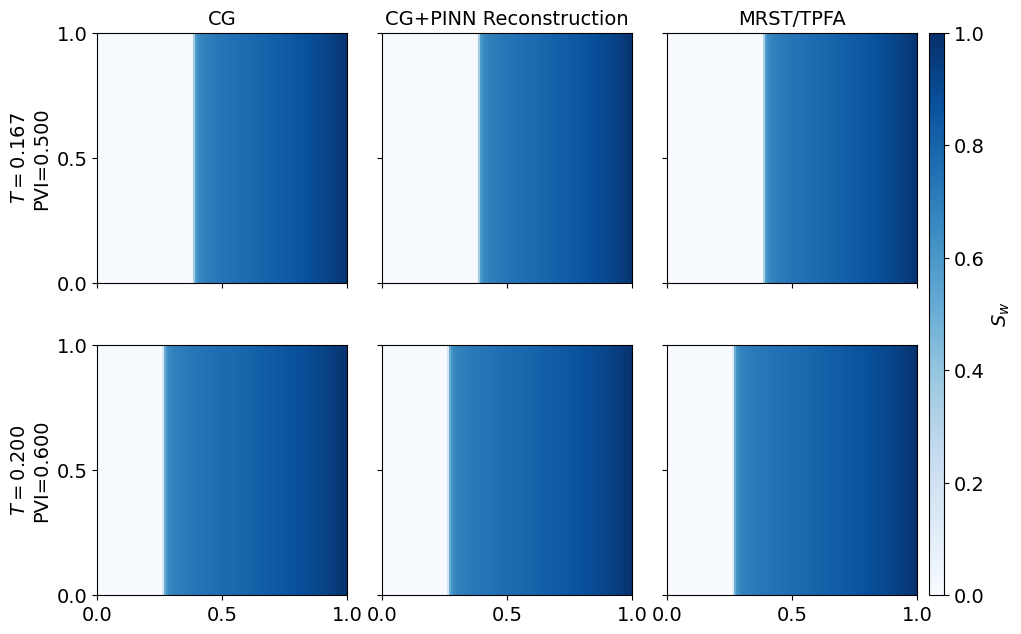

In [13]:
def cell_field_to_grid(field):
    field = np.asarray(field, dtype=float).reshape(-1)
    dx = physdim[0] / nx
    dy = physdim[1] / ny
    ix = np.rint((xc_matrix[:, 0] - 0.5 * dx) / dx).astype(int)
    iy = np.rint((xc_matrix[:, 1] - 0.5 * dy) / dy).astype(int)
    grid = np.full((ny, nx), np.nan, dtype=float)
    grid[iy, ix] = field
    return grid


x_edges = np.linspace(0.0, physdim[0], nx + 1)
y_edges = np.linspace(0.0, physdim[1], ny + 1)
plot_methods = ["CG", "PINN", "MRST"]
plot_titles = {"CG": "CG", "PINN": "CG+PINN Reconstruction", "MRST": "MRST/TPFA"}
row_keys = transport_case_keys
USE_NATIVE_MRST_PANEL = True

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    fig, axes = plt.subplots(2, 3, figsize=(10, 6.8), squeeze=False)
    pcm = None
    for ir, key in enumerate(row_keys):
        for ic, name in enumerate(plot_methods):
            if name == "MRST" and USE_NATIVE_MRST_PANEL:
                field = sw_mrst_native[key]
            else:
                field = transport_results[1.0][key][name]["S"]
            ax = axes[ir, ic]
            pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(field), cmap="Blues", vmin=0.0, vmax=1.0, shading="flat")
            ax.set_aspect("equal")
            ax.set_xlim(0.0, physdim[0])
            ax.set_ylim(0.0, physdim[1])
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.grid(False)
            if ir == 0:
                ax.set_title(plot_titles[name])
            if ic == 0:
                ax.set_ylabel(rf"$T={transport_times[key]:.3f}$" + "\n" + rf"PVI={transport_pvi[key]:.3f}")
            else:
                ax.tick_params(labelleft=False)
            if ir == 0:
                ax.tick_params(labelbottom=False)
    fig.subplots_adjust(left=0.08, right=0.90, bottom=0.07, top=0.94, wspace=0.14, hspace=0.12)
    top = axes[0, -1].get_position()
    bottom = axes[-1, -1].get_position()
    cax = fig.add_axes([top.x1 + 0.012, bottom.y0, 0.015, top.y1 - bottom.y0])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$S_w$")
    if NOFRACTURE_SAVE_FIGURES:
        fig.savefig(NOFRACTURE_OUTDIR / "nofrac_saturation_CG_PINN_MRST.png", dpi=300, bbox_inches="tight")
    plt.show()


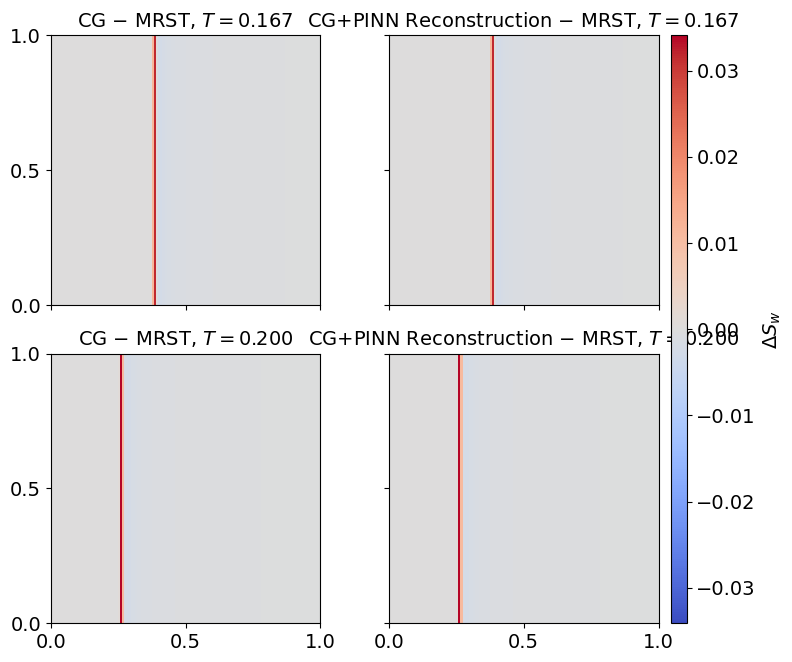

In [14]:
# Difference maps relative to native MRST explicitTransport.
err_fields = {}
for key in transport_case_keys:
    err_fields[(key, "CG")] = transport_results[1.0][key]["CG"]["S"] - sw_mrst_native[key]
    err_fields[(key, "PINN")] = transport_results[1.0][key]["PINN"]["S"] - sw_mrst_native[key]
err_lim = max(float(np.max(np.abs(e))) for e in err_fields.values())
err_lim = max(err_lim, 1.0e-12)

with plt.rc_context({"font.size": 14, "axes.titlesize": 14, "axes.labelsize": 14, "xtick.labelsize": 14, "ytick.labelsize": 14}):
    _nrows_err = len(transport_case_keys)
    fig, axes = plt.subplots(_nrows_err, 2, figsize=(8.0, 3.5 * _nrows_err), squeeze=False)
    pcm = None
    for ir, key in enumerate(transport_case_keys):
        for ic, name in enumerate(("CG", "PINN")):
            err = err_fields[(key, name)]
            ax = axes[ir, ic]
            pcm = ax.pcolormesh(x_edges, y_edges, cell_field_to_grid(err), cmap="coolwarm", vmin=-err_lim, vmax=err_lim, shading="flat")
            ax.set_aspect("equal")
            ax.set_xlim(0.0, physdim[0])
            ax.set_ylim(0.0, physdim[1])
            ax.set_xticks([0.0, 0.5, 1.0])
            ax.set_yticks([0.0, 0.5, 1.0])
            ax.grid(False)
            ax.set_title(rf"{plot_titles[name]} $-$ MRST, $T={transport_times[key]:.3f}$")
            if ic > 0:
                ax.tick_params(labelleft=False)
            if ir < _nrows_err - 1:
                ax.tick_params(labelbottom=False)
    fig.subplots_adjust(left=0.08, right=0.88, bottom=0.08, top=0.92, wspace=0.12, hspace=0.18)
    top = axes[0, -1].get_position()
    bottom = axes[-1, -1].get_position()
    cax = fig.add_axes([top.x1 + 0.015, bottom.y0, 0.020, top.y1 - bottom.y0])
    cbar = fig.colorbar(pcm, cax=cax)
    cbar.set_label(r"$\Delta S_w$")
    if NOFRACTURE_SAVE_FIGURES:
        fig.savefig(NOFRACTURE_OUTDIR / "nofrac_saturation_difference_CG_PINN_minus_MRST.png", dpi=300, bbox_inches="tight")
    plt.show()


In [15]:
print("No-fracture control summary")
print("  time    PVI    method    RMSE vs MRST   max|e|      balance residual (% injected)   dt-ref RMSE")
for key in transport_case_keys:
    for name in ("CG", "PINN", "MRST"):
        S = transport_results[1.0][key][name]["S"]
        meta = transport_results[1.0][key][name]["meta"]
        S_half = transport_results[0.5][key][name]["S"]
        print(
            f"  {transport_times[key]:.5f} {transport_pvi[key]:6.3f} {name:<7} "
            f"{rmse(S, sw_mrst_native[key]):13.4e} {maxabs(S, sw_mrst_native[key]):10.4e} "
            f"{meta['water_balance_error_pct_in']:28.4e} {rmse(S, S_half):12.4e}"
        )


No-fracture control summary
  time    PVI    method    RMSE vs MRST   max|e|      balance residual (% injected)   dt-ref RMSE
  0.16667  0.500 CG         3.0525e-03 3.1892e-02                   5.5511e-13   7.5596e-03
  0.16667  0.500 PINN       3.0525e-03 3.1892e-02                   5.5511e-13   7.5596e-03
  0.16667  0.500 MRST       3.0525e-03 3.1892e-02                  -2.4425e-13   7.5596e-03
  0.20000  0.600 CG         3.2138e-03 3.4108e-02                  -2.5905e-13   8.9653e-03
  0.20000  0.600 PINN       3.2138e-03 3.4108e-02                  -2.5905e-13   8.9653e-03
  0.20000  0.600 MRST       3.2138e-03 3.4108e-02                  -2.2204e-13   8.9653e-03
